## Required Imports

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from torchvision.datasets import MNIST  # using MNIST for simple demonstration
from sklearn.decomposition import PCA

## Data Transforms

In [3]:
transform = transforms.Compose(
    [
        transforms.Resize((32, 32)), # for MNIST dataset, we resize the image to 32x32 for convenience purpose
        transforms.ToTensor(), # convert the image to a tensor  
    ]
)

# load the MNIST dataset
train_dataset = MNIST(root='../../data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='../../data', train=False, download=True, transform=transform)

## Set the Device

In [4]:
# define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Exploring the Data

In [5]:
for image, label in train_dataset:
    print('-'*100)
    print('Basic Image Stats:')
    print(f'Image shape: {image.shape}.')
    print(f'Label: {label}.')
    print(f'Image min: {image.min()}.')
    print(f'Image max: {image.max()}.')
    print('-'*100)
    print(f'Image pixels:\n {image}.')
    print('-'*100)
    break

----------------------------------------------------------------------------------------------------
Basic Image Stats:
Image shape: torch.Size([1, 32, 32]).
Label: 5.
Image min: 0.0.
Image max: 0.9921568632125854.
----------------------------------------------------------------------------------------------------
Image pixels:
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]).
----------------------------------------------------------------------------------------------------


## The Vanilla Autoencoder

In [6]:
class Autoencoder(nn.Module):
    """A simple autoencoder model. The encoder network is a stack of linear layers with ReLU activation functions
    as nonlinearities. The autoencoder network is trained to learn a compressed representation of the data.
    """
    def __init__(self, bottleneck_size: int=2):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 32),
            nn.Sigmoid() # ensure the output is in the range [0, 1] for visualization and reconstruction
                         # to ensure the output is in the range [-1, 1], we can use nn.Tanh() instead of nn.Sigmoid()
        )
    
    def encode(self, x):
        """Encoder function to encode the image to a latent space.
        """
        return self.encoder(x)
    
    def decode(self, x):
        """Decoder function to decode the latent space to an image.
        """
        x = self.decoder(x)
        x = x.reshape(-1, 1, 32, 32) # reshape the output to the original image shape
        return x
    
    def forward(self, x):
        b, c, h, w = x.shape

        x = x.flatten(start_dim=1) # flatten the image to a 1D vector starting from the second dimension

        encoded = self.encode(x) # encode the image to a latent space
        decoded = self.decode(encoded) # decode the latent space to an image

        return encoded, decoded

### A Simple Forward Pass

In [7]:
model = Autoencoder()
rand = torch.randn(2, 1, 32, 32)
model(rand)

(tensor([[-0.1267,  0.0293],
         [-0.1113,  0.0238]], grad_fn=<AddmmBackward0>),
 tensor([[[[0.5167, 0.4937, 0.4780,  ..., 0.5004, 0.4742, 0.5086],
           [0.5068, 0.5076, 0.5090,  ..., 0.4813, 0.4610, 0.4944],
           [0.5338, 0.4866, 0.5230,  ..., 0.5007, 0.5001, 0.4879],
           ...,
           [0.5024, 0.5138, 0.5069,  ..., 0.5007, 0.4845, 0.5323],
           [0.5036, 0.5198, 0.4868,  ..., 0.4823, 0.4979, 0.5095],
           [0.5166, 0.4877, 0.5139,  ..., 0.5026, 0.5352, 0.4853]]],
 
 
         [[[0.5167, 0.4936, 0.4782,  ..., 0.5003, 0.4742, 0.5083],
           [0.5069, 0.5074, 0.5091,  ..., 0.4812, 0.4611, 0.4944],
           [0.5339, 0.4868, 0.5226,  ..., 0.5005, 0.5002, 0.4881],
           ...,
           [0.5023, 0.5137, 0.5069,  ..., 0.5009, 0.4844, 0.5320],
           [0.5036, 0.5196, 0.4867,  ..., 0.4824, 0.4977, 0.5093],
           [0.5165, 0.4880, 0.5139,  ..., 0.5025, 0.5350, 0.4855]]]],
        grad_fn=<ViewBackward0>))

## Training

In [8]:
def train(
    model: nn.Module,
    train_dataset: Dataset,
    test_dataset: Dataset,
    batch_size: int,
    training_iterations: int,
    eval_iterations: int
    ):

        print("Training the model...")
        print(model)

        model  = model.to(device)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        optimizer = optim.Adam(model.parameters(), lr=0.0005)

        train_loss = []
        eval_loss = []
        train_losses = []
        eval_losses = []

        encoded_data_per_eval = []

        pbar = tqdm(range(training_iterations), desc="Training")
        last_eval_loss = None

        train = True

        global_step = 0

        while train:
            model.train()
            for images, labels in train_loader:
                images = images.to(device)

                optimizer.zero_grad()
                
                encoded, recon = model(images)

                loss = torch.mean((images - recon) ** 2) # compute the mean squared error
                train_loss.append(loss.item())

                loss.backward()
                optimizer.step()

                if global_step % eval_iterations == 0:
                    model.eval()
                    encoded_evals = []

                    for images, labels in test_loader:

                        with torch.no_grad():
                            images = images.to(device)
                        
                        encoded, recon = model(images)

                        loss = torch.mean((images - recon) ** 2)
                        eval_loss.append(loss.item())

                        # store the encoded data and the labels
                        encoded, labels = encoded.cpu().flatten(1), labels.reshape(-1, 1)
                        encoded_evals.append(torch.cat((encoded, labels), axis=-1))
                    
                    encoded_data_per_eval.append(torch.concatenate(encoded_evals).detach())
                    
                    train_loss = np.mean(train_loss)
                    eval_loss = np.mean(eval_loss)
                    last_eval_loss = eval_loss
                    
                    train_losses.append(train_loss)
                    eval_losses.append(eval_loss)

                    print(f'training loss: {train_loss:.4f}, eval loss: {eval_loss:.4f}')
                    
                    # reset the loss values for the next evaluation
                    train_loss = []
                    eval_loss = []
                
                global_step += 1
                pbar.update(1)

                if global_step >= training_iterations:
                    print("Training complete.")
                    train = False
                    break
        
        # store the encoded data as numpy arrays for each evaluation
        encoded_data_per_eval = [i.numpy() for i in encoded_data_per_eval]  # convert tensors to numpy (avoids np.array deprecation with PyTorch)

        return model, train_losses, eval_losses, encoded_data_per_eval

In [9]:
# start with a fresh model
model = Autoencoder(bottleneck_size=2)

In [10]:
model, train_losses, eval_losses, encoded_data_per_eval = train(
    model,
    train_dataset,
    test_dataset,
    batch_size=64,
    training_iterations=5000,
    eval_iterations=250)

Training the model...
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1024, bias=True)
    (7): Sigmoid()
  )
)


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

training loss: 0.2196, eval loss: 0.2199
training loss: 0.0767, eval loss: 0.0530
training loss: 0.0495, eval loss: 0.0472
training loss: 0.0459, eval loss: 0.0451
training loss: 0.0443, eval loss: 0.0441
training loss: 0.0431, eval loss: 0.0426
training loss: 0.0418, eval loss: 0.0409
training loss: 0.0399, eval loss: 0.0395
training loss: 0.0391, eval loss: 0.0386
training loss: 0.0379, eval loss: 0.0376
training loss: 0.0375, eval loss: 0.0370
training loss: 0.0370, eval loss: 0.0365
training loss: 0.0364, eval loss: 0.0361
training loss: 0.0360, eval loss: 0.0357
training loss: 0.0357, eval loss: 0.0353
training loss: 0.0350, eval loss: 0.0350
training loss: 0.0349, eval loss: 0.0347
training loss: 0.0347, eval loss: 0.0345
training loss: 0.0341, eval loss: 0.0340
training loss: 0.0342, eval loss: 0.0338
Training complete.


## Plot the Embedding Space through Training

Now we can write a function that takes in the `encoded_data_per_eval` from the training output, and create an animation of the embedding space to see how the neural network learns. Note that the first two columns of the `encoded_data_per_eval` denote the principal component axes where the model decides to place the embeddings, and the last column denotes the corresponding class labels of the embeddings.

In [11]:
print(encoded_data_per_eval[0])

[[-0.14538176  0.08442141  7.        ]
 [-0.16062658  0.08959581  2.        ]
 [-0.13824245  0.08849195  1.        ]
 ...
 [-0.1566444   0.0910572   4.        ]
 [-0.16958809  0.07927442  5.        ]
 [-0.16299549  0.10665251  6.        ]]


In [12]:
from matplotlib.animation import FuncAnimation, PillowWriter

def generate_embedding_animation(
    encodings: np.ndarray | list[np.ndarray],
    title: str = "Autoencoder Embedding Space",
    *,
    output_path: str | None = None,
    eval_iterations: int = 250,
    fps: int = 4,
):
    """
    Generate a static plot or GIF of the embedding space.
    Pass a single array for a static plot, or a list of arrays for a GIF.
    """
    def _plot_frame(ax, data: np.ndarray, frame_title: str, x_lim=None, y_lim=None):
        df = pd.DataFrame(data, columns=["x", "y", "class"])
        df = df.sort_values(by="class")
        df["class"] = df["class"].astype(int).astype(str)
        for label, coordinates in df.groupby("class"):
            ax.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
        ax.set_title(frame_title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        if x_lim is not None:
            ax.set_xlim(x_lim)
        if y_lim is not None:
            ax.set_ylim(y_lim)
        ax.legend()

    if isinstance(encodings, np.ndarray):
        # Single frame - static plot
        fig, ax = plt.subplots(figsize=(8, 6))
        _plot_frame(ax, encodings, title)
        plt.show()
    else:
        # List of frames - GIF
        path = output_path or "embedding_progression.gif"
        all_x = np.concatenate([d[:, 0] for d in encodings])
        all_y = np.concatenate([d[:, 1] for d in encodings])
        x_margin = (all_x.max() - all_x.min()) * 0.05 or 0.1
        y_margin = (all_y.max() - all_y.min()) * 0.05 or 0.1
        x_lim = (all_x.min() - x_margin, all_x.max() + x_margin)
        y_lim = (all_y.min() - y_margin, all_y.max() + y_margin)

        fig, ax = plt.subplots(figsize=(8, 6))

        def update(frame_idx: int):
            ax.clear()
            step = (frame_idx + 1) * eval_iterations
            _plot_frame(ax, encodings[frame_idx], f"Embedding Space at Step {step}", x_lim, y_lim)

        anim = FuncAnimation(fig, update, frames=len(encodings), interval=1000 // fps)
        anim.save(path, writer=PillowWriter(fps=fps))
        plt.close()
        print(f"GIF saved to {path}")

In [13]:
# Generate GIF of training progression
generate_embedding_animation(
    encoded_data_per_eval,
    output_path="embedding_progression.gif",
    eval_iterations=250,
)

GIF saved to embedding_progression.gif


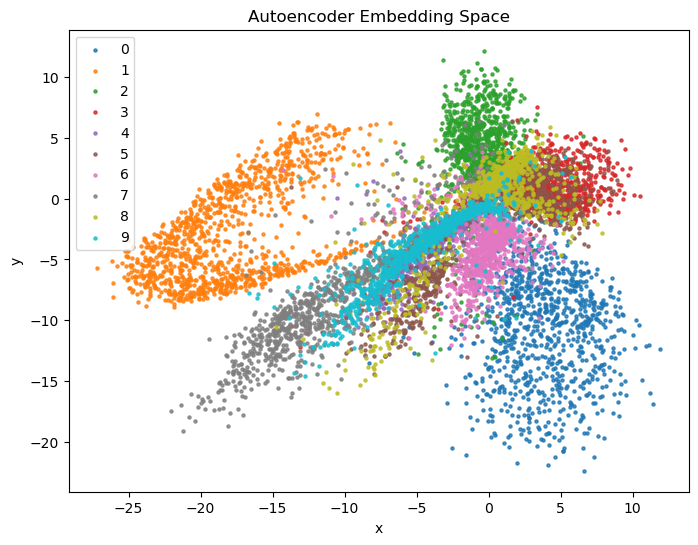

In [14]:
generate_embedding_animation(encoded_data_per_eval[-1], "Autoencoder Embedding Space")

The above plot demonstrates the compressed latent space of the model. If we take a look at the plot and the corresponding labels, we can see some effects of clustering here, for instance, the points representing "4"(purple) and "9" (blue) are very close to each other, coincide with their visual appearances.

Now let's see the progression.

![Embedding progression](embedding_progression.gif)

## A Linear Autoencoder is Just Another PCA

In [15]:
class LinearAutoencoder(nn.Module):
    def __init__(self, bottleneck_size: int=2):
        """
        A linear autoencoder with simple linear layers to compress and decompress the images.
        """
        super(LinearAutoencoder, self).__init__()

        self.encoder = nn.Linear(32 * 32, bottleneck_size)
        self.decoder = nn.Linear(bottleneck_size, 32 * 32)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        decoded = decoded.reshape(-1, 1, 32, 32) # reshape the output to the original image shape

        return encoded, decoded

In [21]:
model = LinearAutoencoder(bottleneck_size=2) # initialize the model

### Training the Linear Autoencoder

In [22]:
model, train_losses, eval_losses, encoded_data_per_eval = train(model, train_dataset, test_dataset, batch_size=64, training_iterations=25000, eval_iterations=250)

Training the model...
LinearAutoencoder(
  (encoder): Linear(in_features=1024, out_features=2, bias=True)
  (decoder): Linear(in_features=2, out_features=1024, bias=True)
)


Training:   0%|          | 0/25000 [00:00<?, ?it/s]

training loss: 0.2651, eval loss: 0.2682
training loss: 0.2140, eval loss: 0.1618
training loss: 0.1177, eval loss: 0.0877
training loss: 0.0720, eval loss: 0.0634
training loss: 0.0593, eval loss: 0.0575
training loss: 0.0564, eval loss: 0.0561
training loss: 0.0555, eval loss: 0.0556
training loss: 0.0553, eval loss: 0.0554
training loss: 0.0551, eval loss: 0.0552
training loss: 0.0549, eval loss: 0.0551
training loss: 0.0549, eval loss: 0.0549
training loss: 0.0544, eval loss: 0.0547
training loss: 0.0543, eval loss: 0.0545
training loss: 0.0543, eval loss: 0.0543
training loss: 0.0539, eval loss: 0.0541
training loss: 0.0538, eval loss: 0.0538
training loss: 0.0536, eval loss: 0.0535
training loss: 0.0530, eval loss: 0.0533
training loss: 0.0529, eval loss: 0.0530
training loss: 0.0526, eval loss: 0.0526
training loss: 0.0524, eval loss: 0.0523
training loss: 0.0520, eval loss: 0.0520
training loss: 0.0519, eval loss: 0.0518
training loss: 0.0516, eval loss: 0.0515
training loss: 0

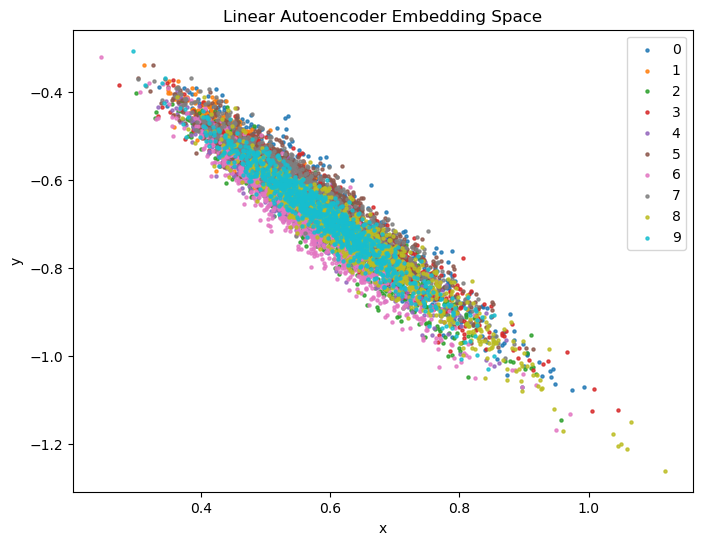

In [18]:
generate_embedding_animation(encoded_data_per_eval[3], "Linear Autoencoder Embedding Space")

### Compare to PCA

In [19]:
display(test_dataset[0])
display(test_dataset[0][0].shape)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 7)

torch.Size([1, 32, 32])

As from above, there are two entries of each data sample in the test dataset, with each image stored as a $1 \times 32 \times 32$ tensor.

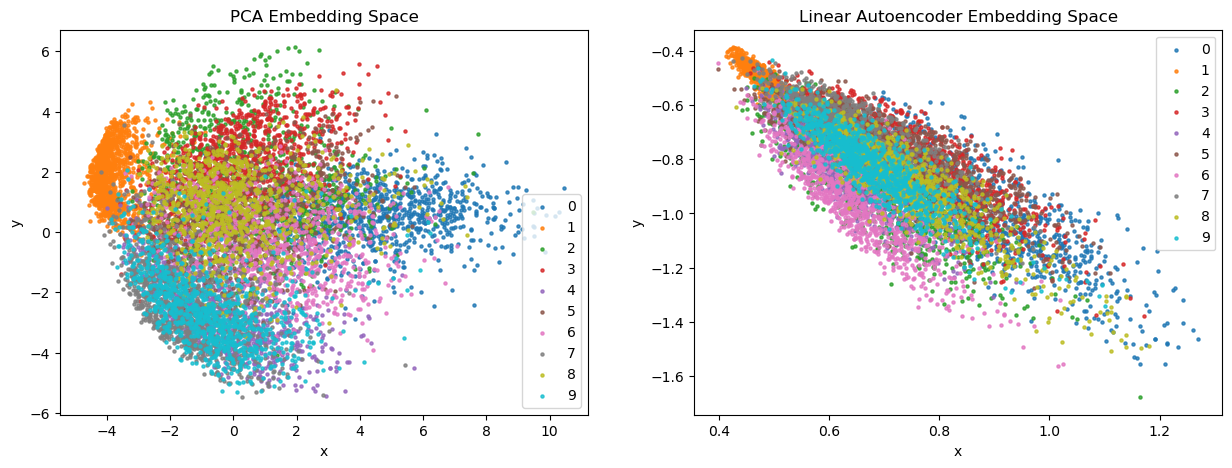

In [20]:
# convert the data in the test dataset to numpy arrays
data = torch.cat([d[0].flatten(1) for d in test_dataset], dim=0).numpy()
labels = np.array([test_sample[1] for test_sample in test_dataset]).reshape(-1, 1)

# compute PCA encodings (add label column so we have x, y, class like autoencoder encodings)
pca = PCA(n_components=2)
pca_encodings = pca.fit_transform(data)
pca_encodings = np.concatenate((pca_encodings, labels), axis=-1)
pca_encodings = pd.DataFrame(pca_encodings, columns=["x", "y", "class"])
pca_encodings = pca_encodings.sort_values(by="class")
pca_encodings["class"] = pca_encodings["class"].astype(int).astype(str)

# get the last row of Linear Autoencoder encodings
linear_autoencoder_encodings = encoded_data_per_eval[-1]
linear_autoencoder_encodings = pd.DataFrame(linear_autoencoder_encodings, columns=["x", "y", "class"])
linear_autoencoder_encodings = linear_autoencoder_encodings.sort_values(by="class")
linear_autoencoder_encodings["class"] = linear_autoencoder_encodings["class"].astype(int).astype(str)

# plot the PCA and Linear Autoencoder encodings
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# plot PCA encodings
for label, coordinates in pca_encodings.groupby("class"):
    ax1.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
ax1.set_title("PCA Embedding Space")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()

for label, coordinates in linear_autoencoder_encodings.groupby("class"):
    ax2.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
ax2.set_title("Linear Autoencoder Embedding Space")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()

plt.show()